In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Loads the aggregate data generated by query_data.py
df = pd.read_csv('monthly_merchant_trends.csv')

df['total_revenue'] = df['total_revenue'].round(2)
df['avg_transaction_value'] = df['avg_transaction_value'].round(2)

df.head(6)

,merchant,transaction_month,unique_customers,total_revenue,avg_transaction_value
0,Target,2026-01,19,6367.39,335.13
1,eBay,2026-01,17,5722.84,336.64
2,Walmart,2026-01,11,3574.81,324.98
3,Best Buy,2026-01,7,2349.28,335.61
4,Etsy,2026-01,7,2105.13,300.73
5,Amazon,2026-01,8,1935.29,241.91


In [27]:
# Pivot so index = months, columns = merchants, values = total_revenue
revenue_pivot = df.pivot(index='transaction_month', columns='merchant', values='total_revenue')
revenue_pivot

merchant,Amazon,Best Buy,Etsy,Target,Walmart,eBay
transaction_month,,,,,,
2026-01,1935.29,2349.28,2105.13,6367.39,3574.81,5722.84
2026-02,2023.08,2673.73,4086.44,4778.66,4168.64,3277.69
2026-03,2895.59,4373.18,3163.86,2406.09,2551.07,2446.57


In [28]:
# Table to display change in unique customers from Jan to Mar 2026
customer_pivot = df.pivot(index='merchant', columns='transaction_month', values='unique_customers')

customer_pivot['Net Change'] = customer_pivot['2026-03'] - customer_pivot['2026-01']

customer_pivot

transaction_month,2026-01,2026-02,2026-03,Net Change
merchant,,,,
Amazon,8,7,12,4
Best Buy,7,9,14,7
Etsy,7,13,11,4
Target,19,13,8,-11
Walmart,11,17,9,-2
eBay,17,11,7,-10


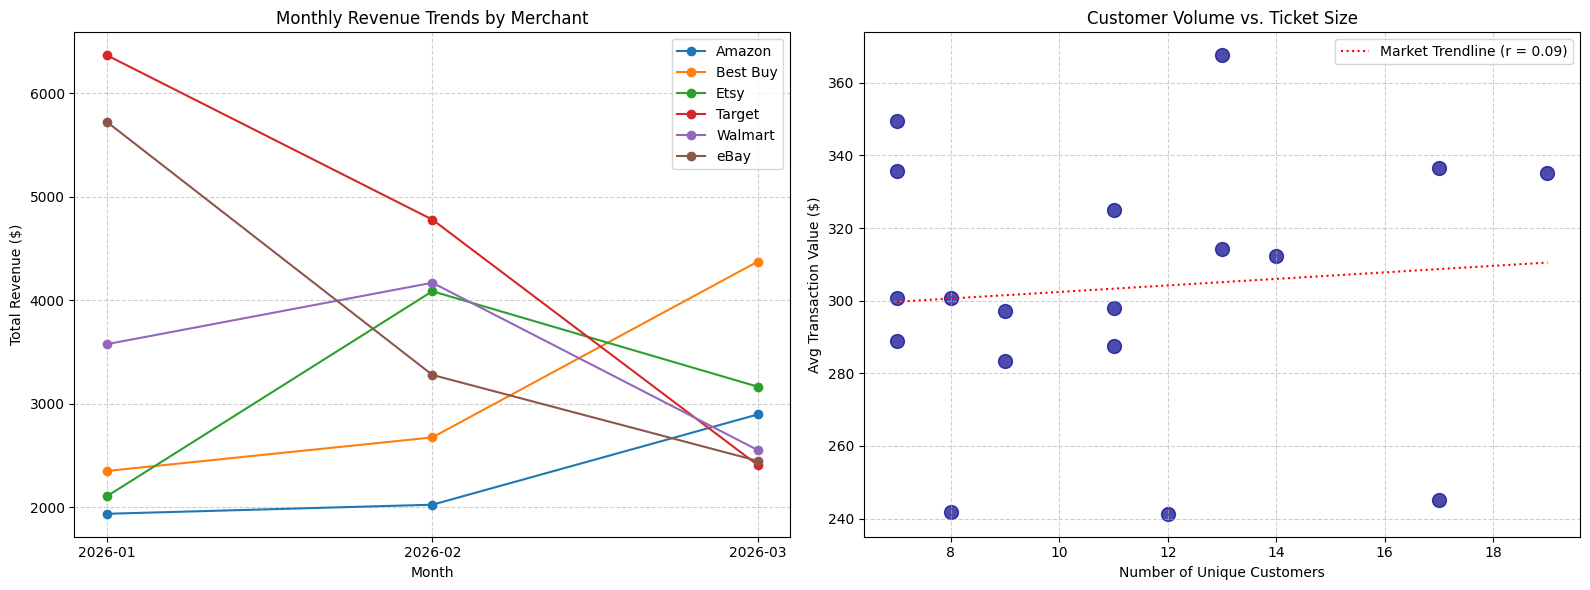

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Total Revenue Trends (Line Chart)
for merchant in revenue_pivot.columns:
    ax1.plot(revenue_pivot.index, revenue_pivot[merchant], marker='o', label=merchant)
ax1.set_title('Monthly Revenue Trends by Merchant')
ax1.set_xlabel('Month')
ax1.set_ylabel('Total Revenue ($)')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# Unique Customers vs Average Transaction Value
ax2.scatter(df['unique_customers'], df['avg_transaction_value'], color='darkblue', s=100, alpha=0.7)

# Calculating the correlation coefficient for the trendline label
correlation_matrix = df['unique_customers'].corr(df['avg_transaction_value'])

# Linear regression for plot 2
m, b = np.polyfit(df['unique_customers'], df['avg_transaction_value'], 1)
x_vals = np.array([df['unique_customers'].min(), df['unique_customers'].max()])

trendline_label = f'Market Trendline (r = {correlation_matrix:.2f})'
ax2.plot(x_vals, m*x_vals + b, color='red', linestyle=':', label=trendline_label)

ax2.set_title('Customer Volume vs. Ticket Size')
ax2.set_xlabel('Number of Unique Customers')
ax2.set_ylabel('Avg Transaction Value ($)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Conclusions

After generating graphs and tables based off the aggregate of the mock data, the trends revealed distinct consumer behaviors across the merchants with data available. The correlation coefficient between customer volume and ticket size is 0.09, which suggests a weak positive correlation between the two variables. Consequently, we can largely disregard the data because of its lack of correlation. Best Buy had the greatest frequency of unique users, while Target shows the greatest loss of customers. Target displayed a short term spike in revenue in January, suggesting a seasonal spike or promotional success which boosted profit in that time. These insights demonstrate how transaction data can be used to give a strong idea of past corporate performance, and draw conclusions on what might come.